In [1]:
from utility import load_test_results, architecture_stats, sample_image

from NeuralNetwork import NeuralNetwork, torch

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.min_rows', 5000)
pd.set_option('display.max_rows', 5000)

In [2]:
classifiers_dict, all_results = load_test_results("Classifier_3")

In [3]:
classifiers_dict

{0: "Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])"}

In [4]:
all_results.head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
0,0,0,0.6,['Conv2'],ADAM,0.0005,32,5,0.00,0.979643,0.081831,16.653449
1,1,0,0.6,['Conv2'],ADAM,0.0005,32,5,0.25,0.982013,0.081874,5.487189
2,2,0,0.6,['Conv2'],ADAM,0.0005,32,5,0.50,0.978109,0.082286,6.504625
3,3,0,0.6,['Conv2'],ADAM,0.0005,32,5,0.75,0.990658,0.081809,22.594679
4,4,0,0.6,['Conv2'],ADAM,0.0005,32,10,0.00,0.989543,0.082294,22.682659
5,5,0,0.6,['Conv2'],ADAM,0.0005,32,10,0.25,0.987451,0.082234,23.158265
6,6,0,0.6,['Conv2'],ADAM,0.0005,32,10,0.50,0.982571,0.082688,26.164194
7,7,0,0.6,['Conv2'],ADAM,0.0005,32,10,0.75,0.984663,0.083696,19.626152
8,8,0,0.6,['Conv2'],ADAM,0.0005,32,15,0.00,0.984663,0.084096,71.370197
9,9,0,0.6,['Conv2'],ADAM,0.0005,32,15,0.25,0.975600,0.082858,14.434333


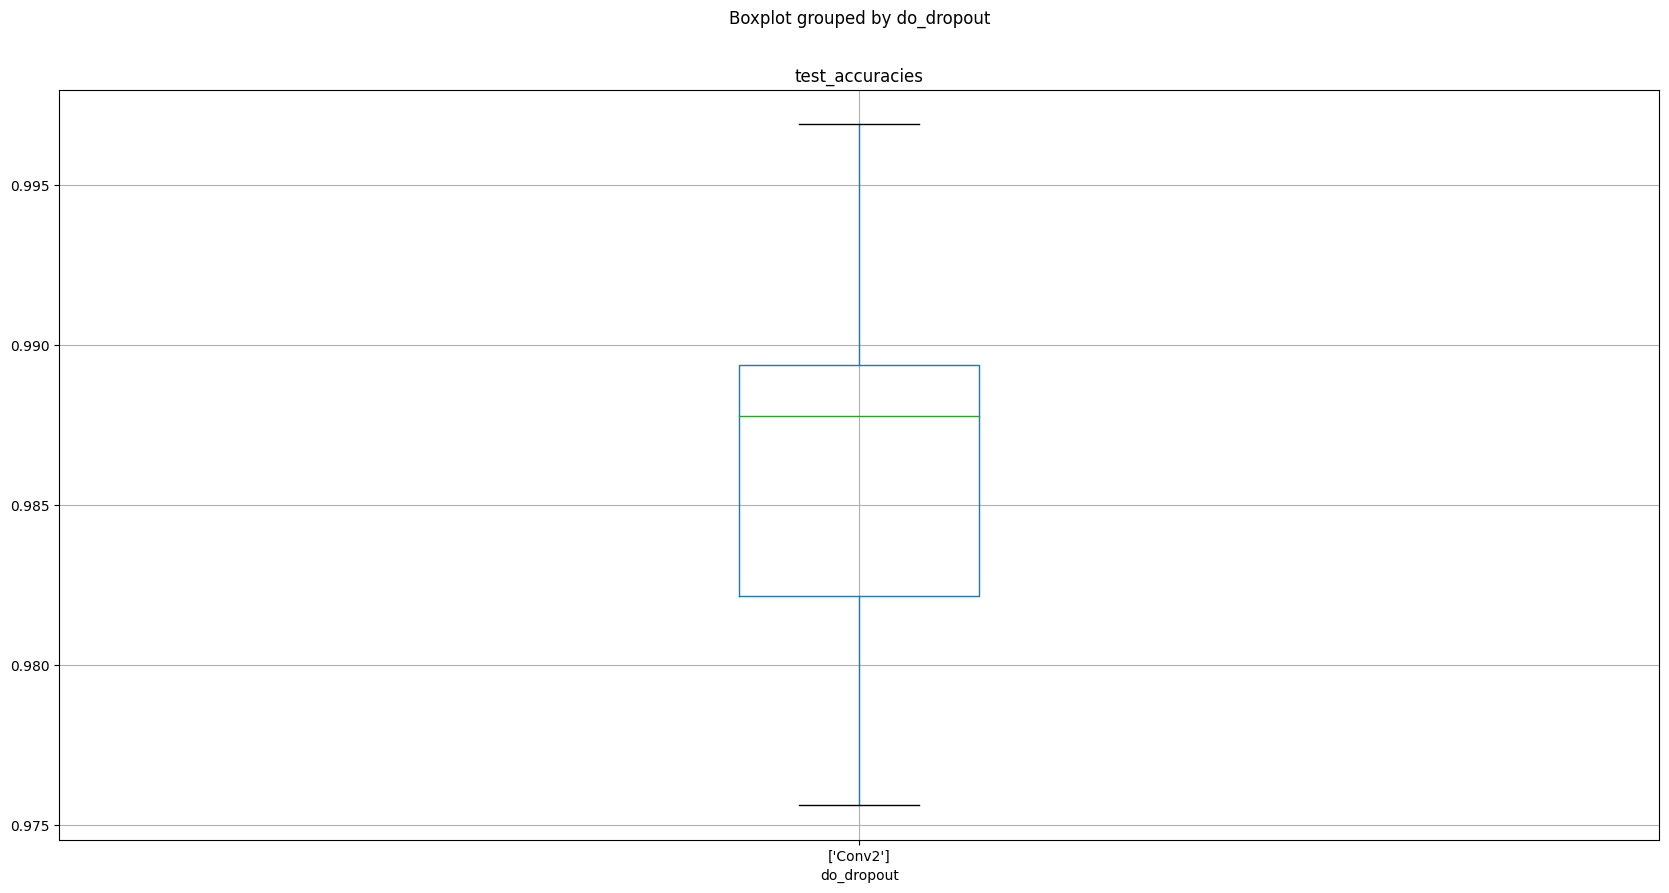

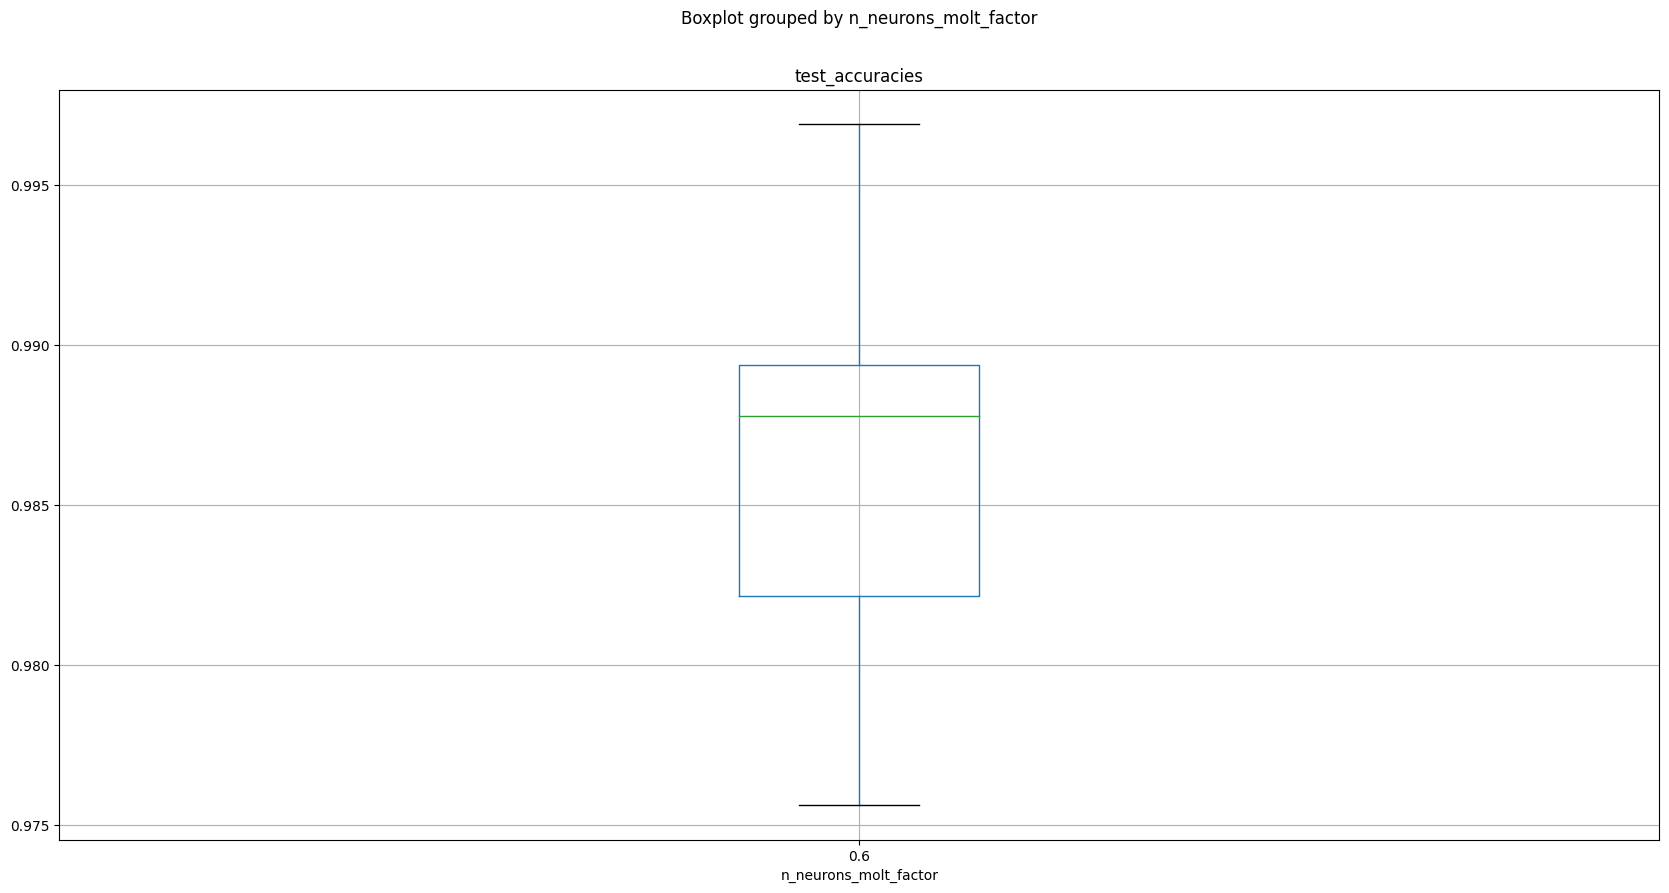

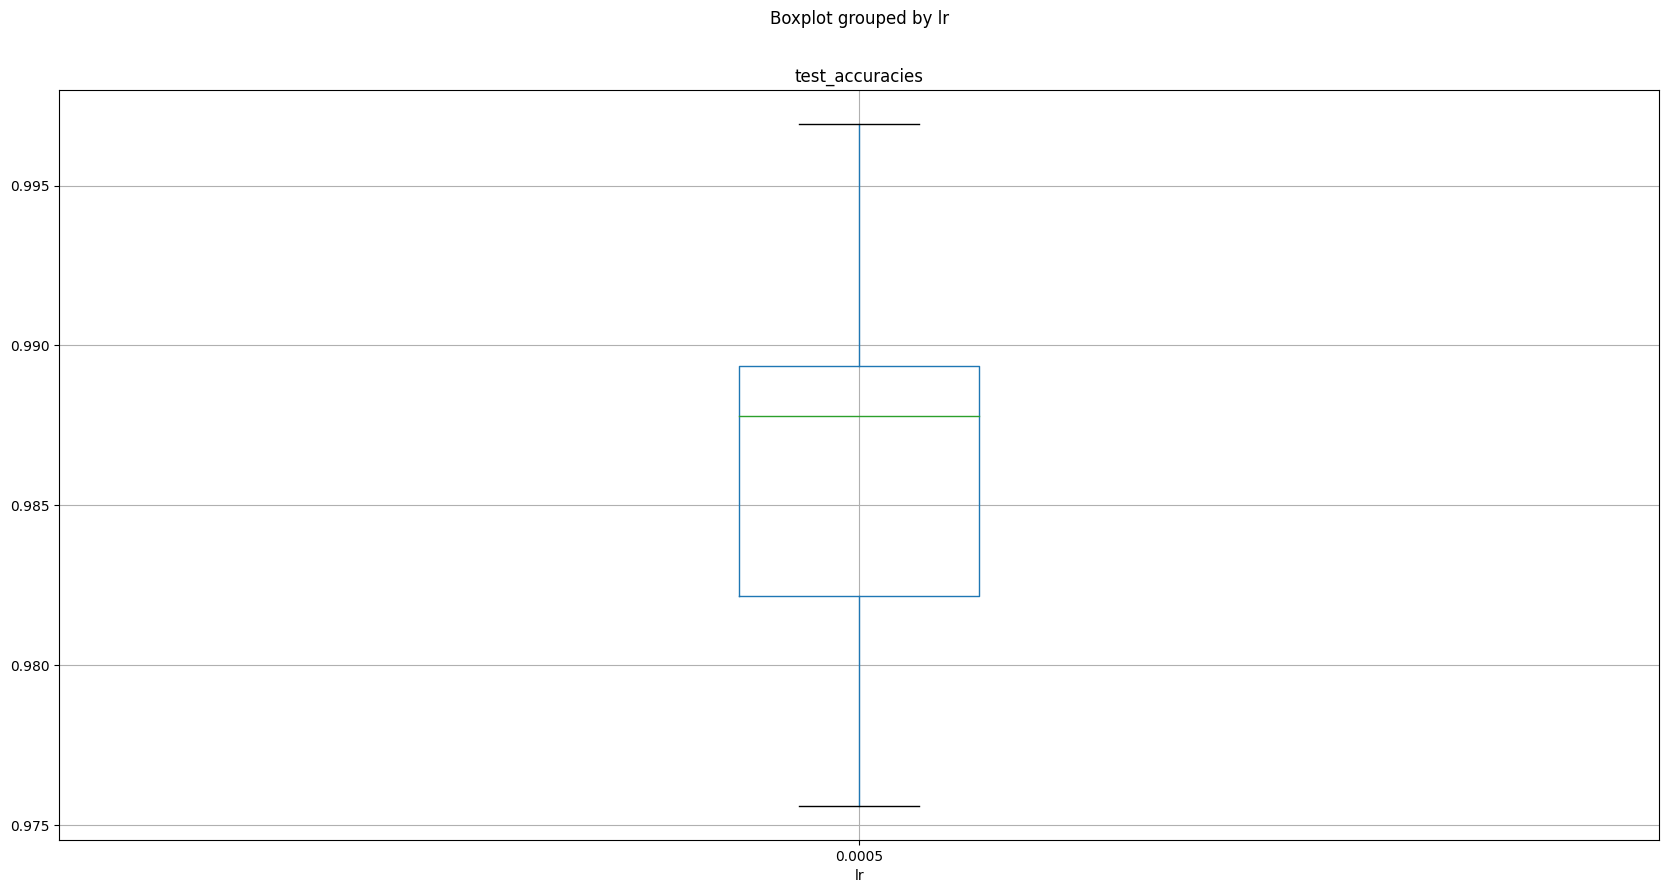

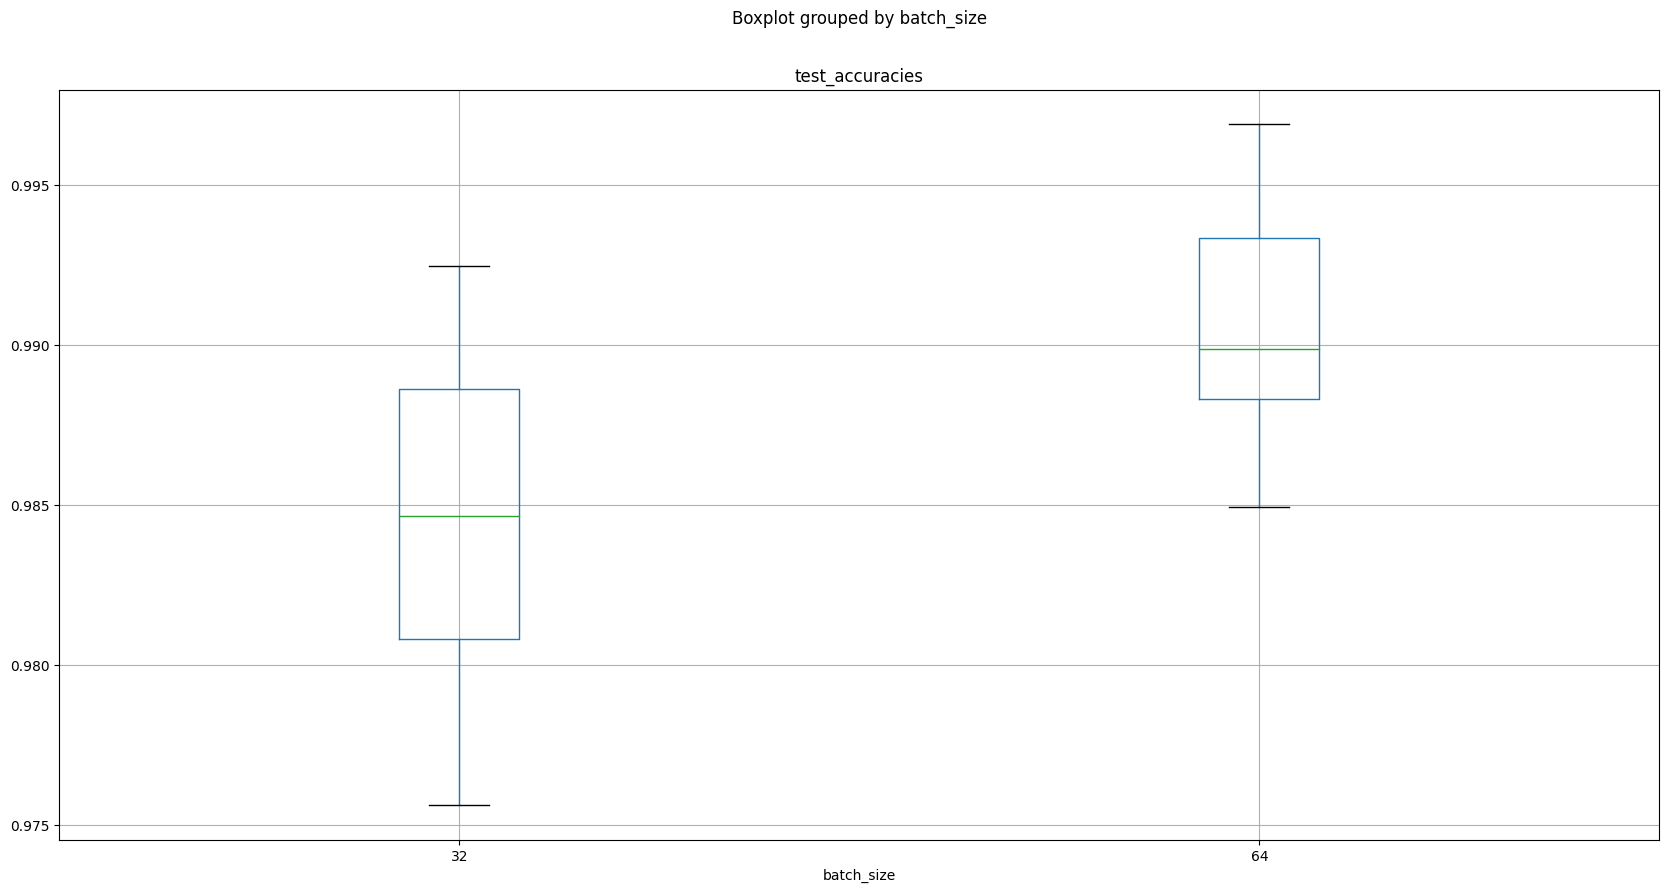

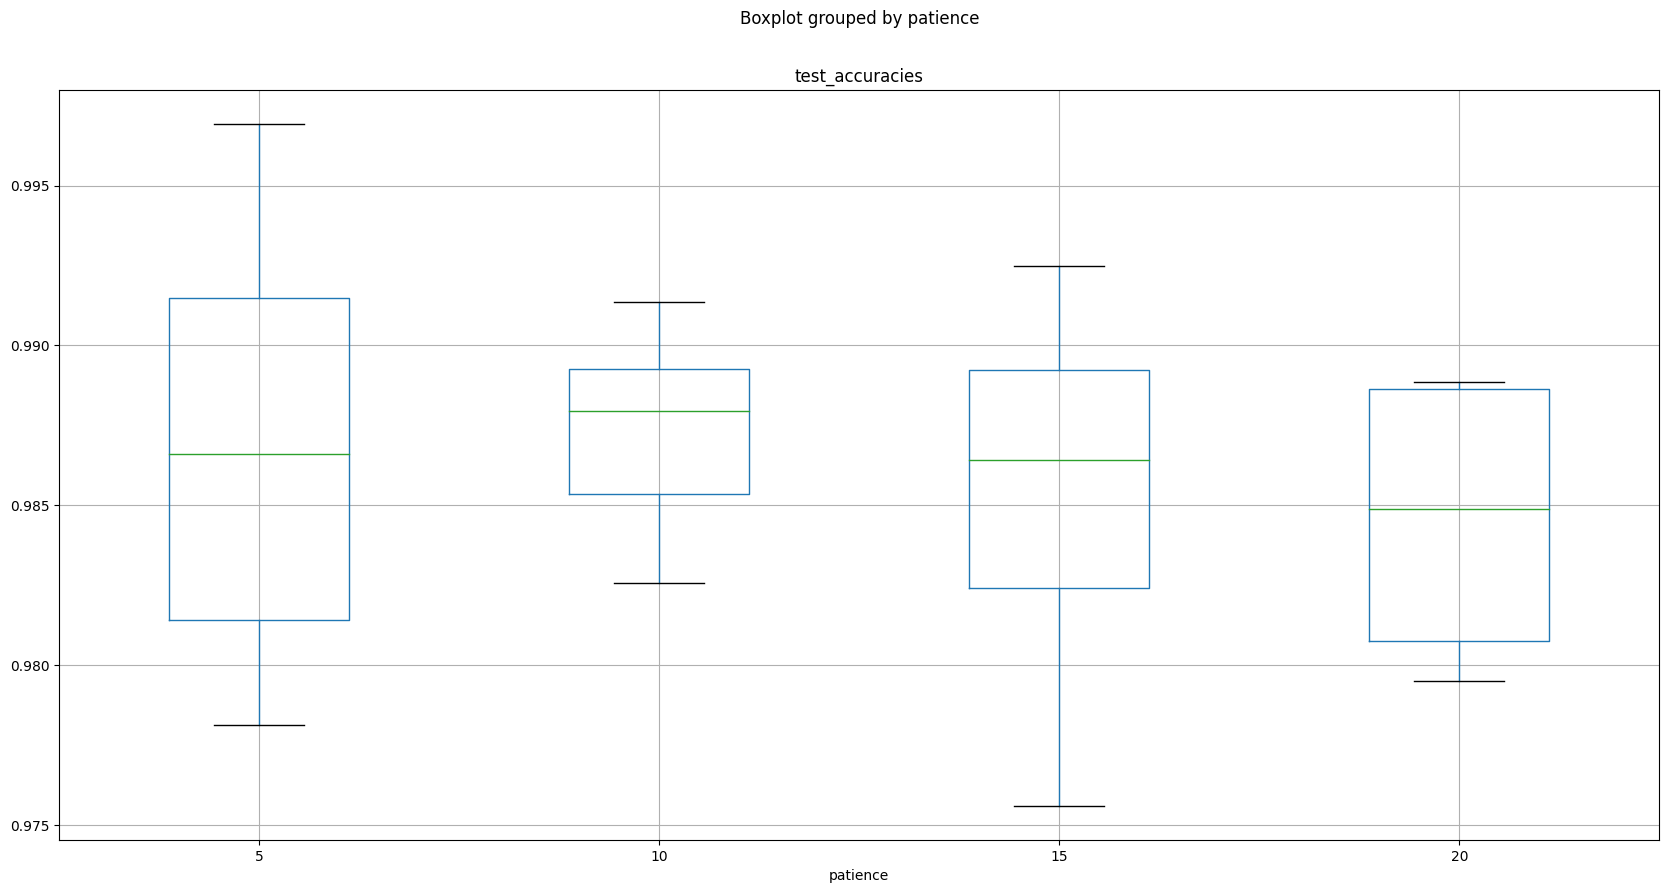

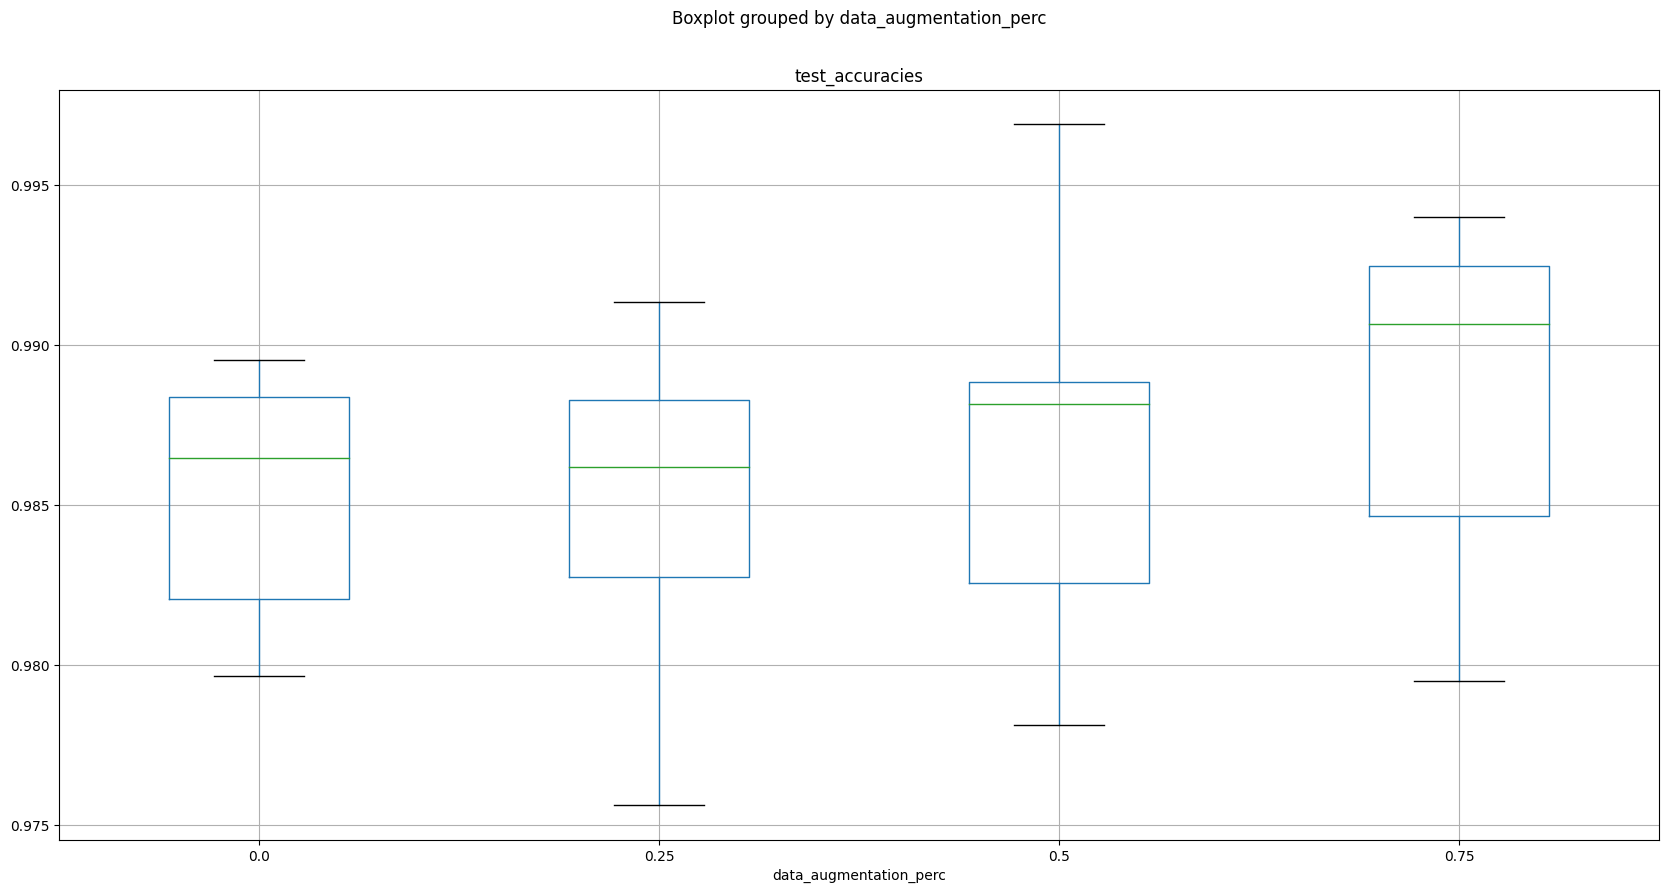

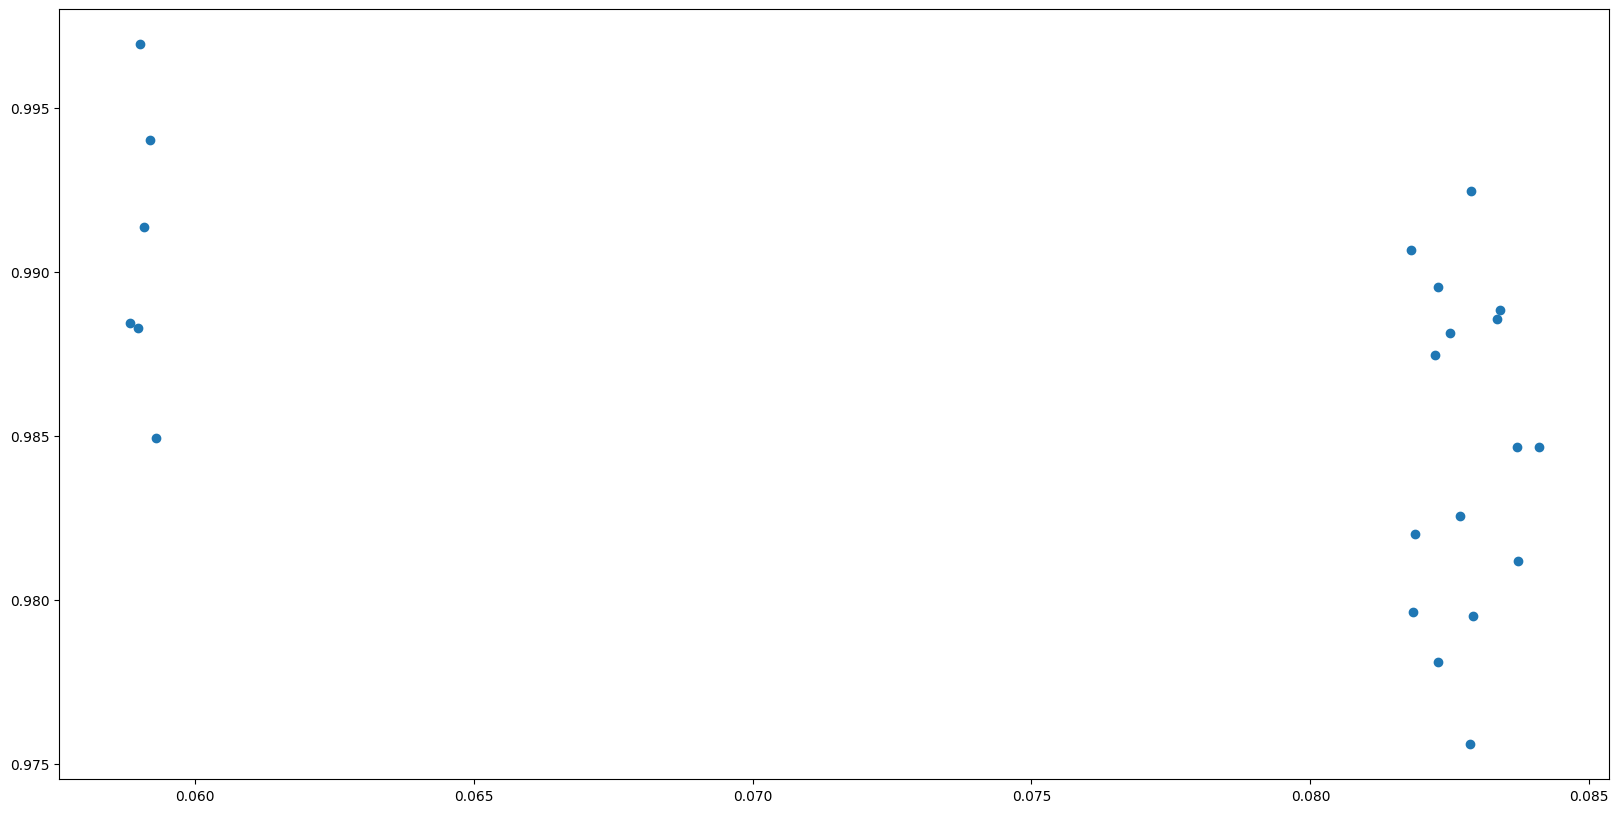

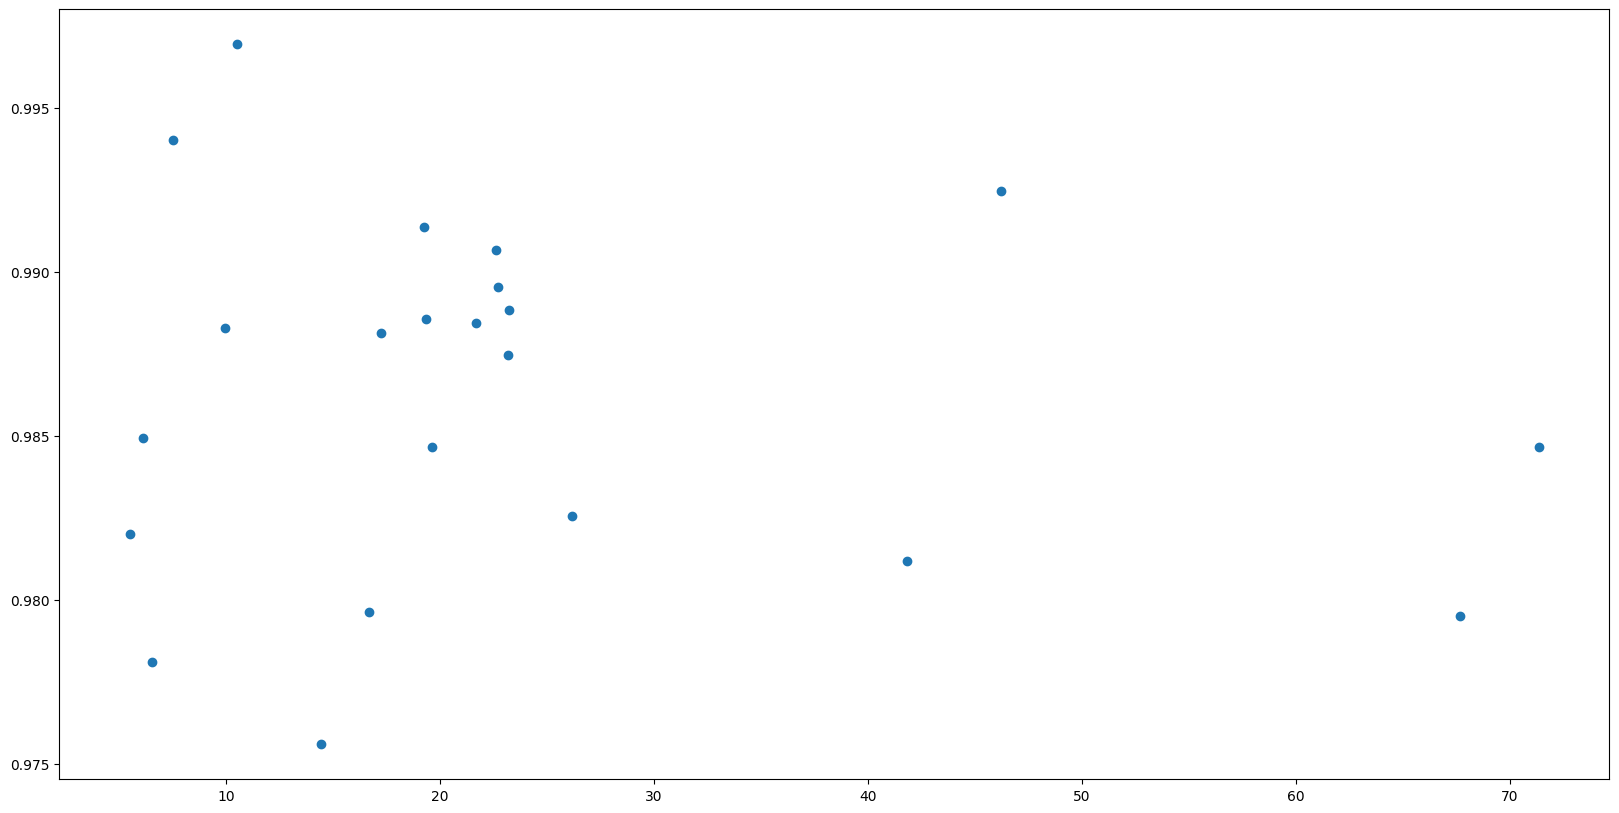

In [5]:
def plot_hyper():
    
    fig,ax=plt.subplots(figsize=(20,10))
    prova = all_results.sort_values(by="do_dropout")
    prova.boxplot(column =["test_accuracies"], by="do_dropout", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="n_neurons_molt_factor", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="lr", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="batch_size", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="patience", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    all_results.boxplot(column =["test_accuracies"], by="data_augmentation_perc", ax=ax)
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["test_times"], all_results["test_accuracies"])
    
    fig,ax=plt.subplots(figsize=(20,10))
    ax.scatter(all_results["train_times"], all_results["test_accuracies"])

plot_hyper()

In [6]:
all_results.sort_values(by=['test_accuracies'], ascending=False).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
18,18,0,0.6,['Conv2'],ADAM,0.0005,64,5,0.50,0.996933,0.059025,10.492833
19,19,0,0.6,['Conv2'],ADAM,0.0005,64,5,0.75,0.994004,0.059198,7.489601
11,11,0,0.6,['Conv2'],ADAM,0.0005,32,15,0.75,0.992471,0.082871,46.230891
21,21,0,0.6,['Conv2'],ADAM,0.0005,64,10,0.25,0.991355,0.059094,19.244346
3,3,0,0.6,['Conv2'],ADAM,0.0005,32,5,0.75,0.990658,0.081809,22.594679
4,4,0,0.6,['Conv2'],ADAM,0.0005,32,10,0.00,0.989543,0.082294,22.682659
14,14,0,0.6,['Conv2'],ADAM,0.0005,32,20,0.50,0.988846,0.083398,23.232047
13,13,0,0.6,['Conv2'],ADAM,0.0005,32,20,0.25,0.988567,0.083342,19.335095
20,20,0,0.6,['Conv2'],ADAM,0.0005,64,10,0.00,0.988427,0.058838,21.663690
16,16,0,0.6,['Conv2'],ADAM,0.0005,64,5,0.00,0.988288,0.058980,9.943361


In [7]:
n_high_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].max()])
n_high_accuracy_architectures

1

In [8]:
high_accuracy_architectures = all_results.sort_values(by=['test_accuracies'], ascending=False).head(n_high_accuracy_architectures)["architecture_id"].unique()
high_accuracy_architectures

array([0])

In [9]:
for model in high_accuracy_architectures:
    architecture_stats(all_results, classifiers_dict, model)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.9863 with standard error: 0.0055

worst accuracy: 0.9756 with hyperparameters:
test_id                           9
optimizer                      ADAM
lr                           0.0005
batch_size                       32
patience                         15
data_augmentation_perc         0.25
test_times                 0.082858
train_times               14.434333
Name: 9, dtype: object 

best accuracy: 0.9969 with hyperparameters:
test_id                          18
optimizer                      ADAM
lr                           0.0005
batch_size                       64
patience                          5
data_augmentation_perc          0.5
test_times                 0.059025
train_times               10.492833
Name: 18, dtype: object 



Loaded model: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])_test_18


Architecture:
name: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8                       [-1, 128,

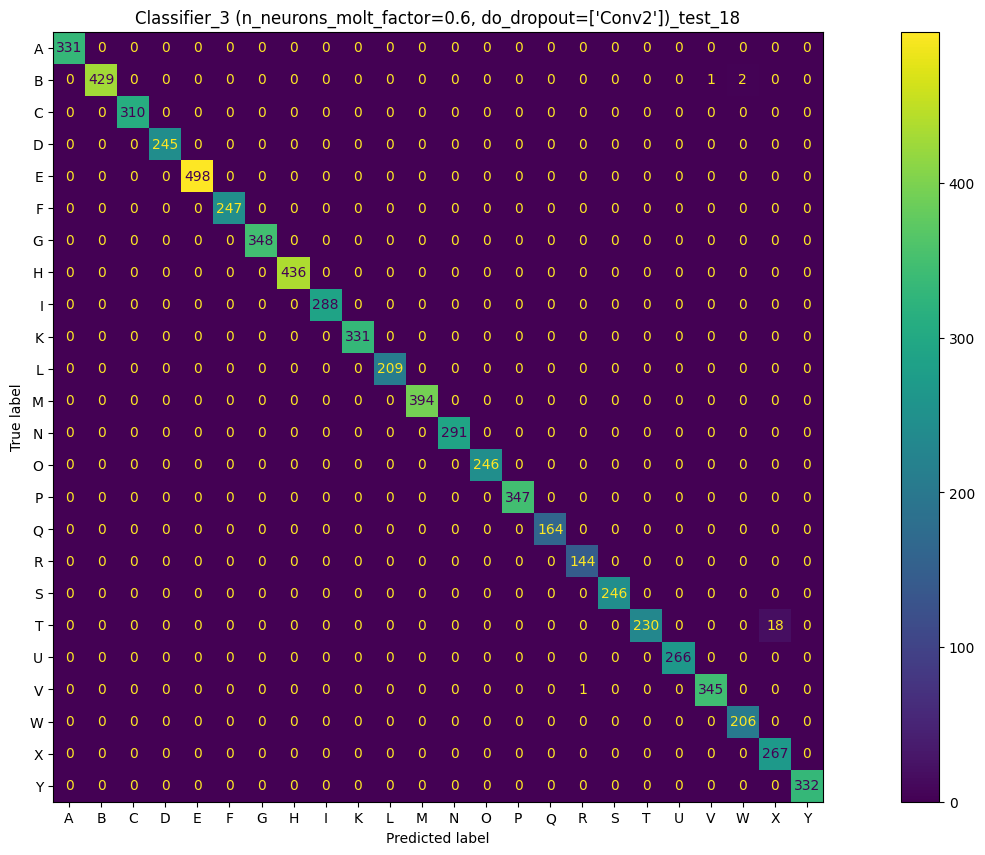

WRONG PREDICTIONS:


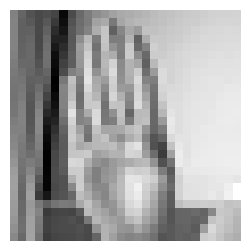

true response: B
predicted: W


{'A': 0.0,
 'B': 0.2282,
 'C': 0.0024,
 'D': 0.0004,
 'E': 0.0124,
 'F': 0.0837,
 'G': 0.0175,
 'H': 0.0316,
 'I': 0.0042,
 'K': 0.0196,
 'L': 0.0512,
 'M': 1e-04,
 'N': 0.0031,
 'O': 0.0005,
 'P': 0.0141,
 'Q': 0.0041,
 'R': 0.0054,
 'S': 0.0011,
 'T': 0.0469,
 'U': 0.0392,
 'V': 0.1091,
 'W': 0.3086,
 'X': 0.0138,
 'Y': 0.0027}

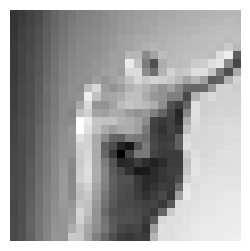

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.2444,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.7556,
 'Y': 0.0}

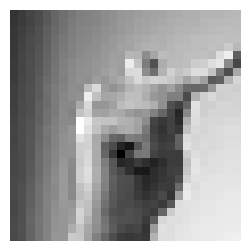

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.3292,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.6707,
 'Y': 0.0}

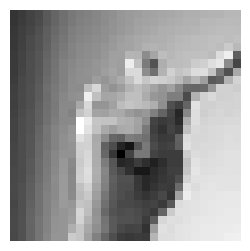

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.2357,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.7643,
 'Y': 0.0}

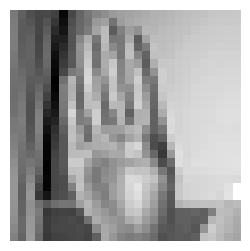

true response: B
predicted: W


{'A': 0.0,
 'B': 0.3138,
 'C': 0.0,
 'D': 0.0005,
 'E': 0.0098,
 'F': 0.0295,
 'G': 0.0003,
 'H': 0.0063,
 'I': 0.0021,
 'K': 0.0233,
 'L': 0.0281,
 'M': 0.0,
 'N': 0.0014,
 'O': 1e-04,
 'P': 0.0126,
 'Q': 0.0018,
 'R': 0.0064,
 'S': 0.0008,
 'T': 0.0229,
 'U': 0.0525,
 'V': 0.1296,
 'W': 0.351,
 'X': 0.0064,
 'Y': 0.0009}

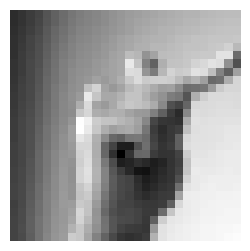

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0339,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9661,
 'Y': 0.0}

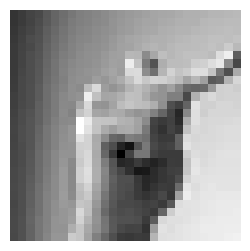

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.2329,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.7671,
 'Y': 0.0}

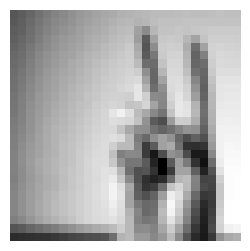

true response: V
predicted: R


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0004,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0013,
 'L': 0.0019,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.7385,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0049,
 'V': 0.2529,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

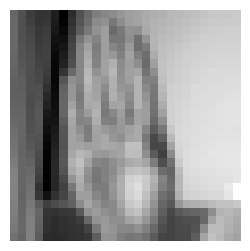

true response: B
predicted: V


{'A': 0.0,
 'B': 1e-04,
 'C': 0.0,
 'D': 0.0468,
 'E': 0.0,
 'F': 0.002,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0069,
 'K': 0.0272,
 'L': 0.0248,
 'M': 0.0005,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0763,
 'Q': 0.0,
 'R': 0.1062,
 'S': 0.0,
 'T': 0.0241,
 'U': 0.1407,
 'V': 0.3435,
 'W': 0.1982,
 'X': 0.0002,
 'Y': 0.0023}

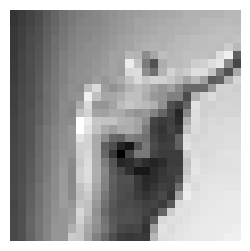

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.2195,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.7805,
 'Y': 0.0}

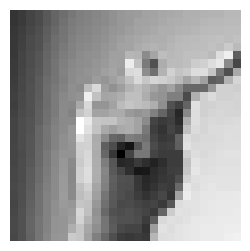

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.2472,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.7528,
 'Y': 0.0}

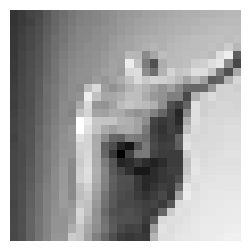

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.4226,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.5774,
 'Y': 0.0}

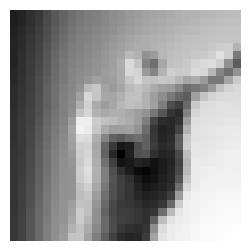

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 1.0,
 'Y': 0.0}

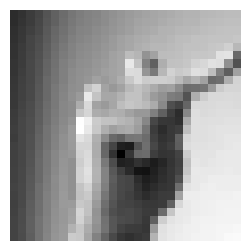

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.039,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.961,
 'Y': 0.0}

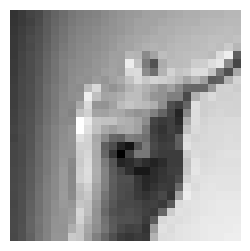

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.4305,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.5694,
 'Y': 0.0}

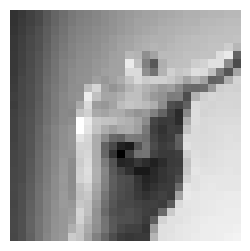

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.1127,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.8873,
 'Y': 0.0}

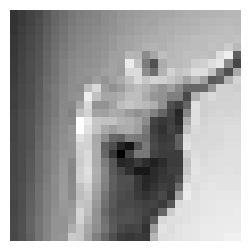

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.3417,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.6583,
 'Y': 0.0}

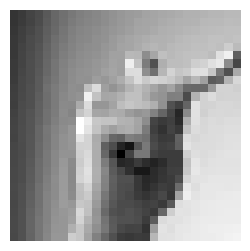

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.2272,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.7728,
 'Y': 0.0}

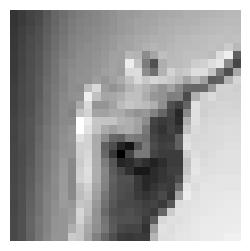

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 1.0,
 'Y': 0.0}

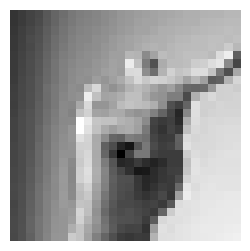

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.1549,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.8451,
 'Y': 0.0}

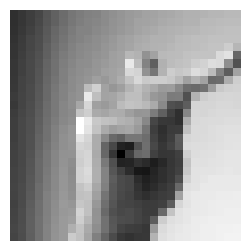

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0616,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.9383,
 'Y': 0.0}

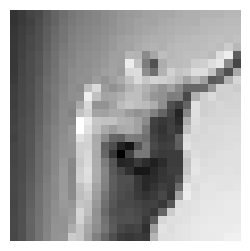

true response: T
predicted: X


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.2977,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.7022,
 'Y': 0.0}

In [19]:
best_model = NeuralNetwork.load_NN(all_results.iloc[18], classifiers_dict, torch.device("cuda"), (28,28))
best_model.explore_wrong_predictions()

In [11]:
best_model.return_stats()

,epochs,train_losses,eval_losses,test_accuracies,training_time_per_epoch
0,1,0.015902,0.000019,0.981456,1.261135
1,2,0.008895,0.000012,0.993865,1.253314
2,3,0.006259,0.000018,0.985639,1.255483
3,4,0.004900,0.000011,0.989403,1.255191
4,5,0.004019,0.000025,0.987591,1.248578
5,6,0.003296,0.000007,0.989124,1.254903
6,7,0.003361,0.000009,0.993586,1.255396
7,8,0.002928,0.000017,0.991355,1.253504
8,9,0.002615,0.000007,0.991076,1.260066
9,10,0.002598,0.000007,0.993028,1.251555


In [12]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(10)

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times
9,9,0,0.6,['Conv2'],ADAM,0.0005,32,15,0.25,0.975600,0.082858,14.434333
2,2,0,0.6,['Conv2'],ADAM,0.0005,32,5,0.50,0.978109,0.082286,6.504625
15,15,0,0.6,['Conv2'],ADAM,0.0005,32,20,0.75,0.979504,0.082910,67.685585
0,0,0,0.6,['Conv2'],ADAM,0.0005,32,5,0.00,0.979643,0.081831,16.653449
12,12,0,0.6,['Conv2'],ADAM,0.0005,32,20,0.00,0.981177,0.083719,41.841014
1,1,0,0.6,['Conv2'],ADAM,0.0005,32,5,0.25,0.982013,0.081874,5.487189
6,6,0,0.6,['Conv2'],ADAM,0.0005,32,10,0.50,0.982571,0.082688,26.164194
7,7,0,0.6,['Conv2'],ADAM,0.0005,32,10,0.75,0.984663,0.083696,19.626152
8,8,0,0.6,['Conv2'],ADAM,0.0005,32,15,0.00,0.984663,0.084096,71.370197
17,17,0,0.6,['Conv2'],ADAM,0.0005,64,5,0.25,0.984941,0.059312,6.081828


In [13]:
n_low_accuracy_architectures = len(all_results[all_results["test_accuracies"]==all_results["test_accuracies"].min()])
n_low_accuracy_architectures

1

In [14]:
all_results.sort_values(by=['test_accuracies'], ascending=True).head(n_low_accuracy_architectures)["architecture_id"].unique()

array([0])

In [15]:
architecture_stats(all_results, classifiers_dict, 0)

Stats for architecture: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2']) (id: 0)
mean accuracy: 0.9863 with standard error: 0.0055

worst accuracy: 0.9756 with hyperparameters:
test_id                           9
optimizer                      ADAM
lr                           0.0005
batch_size                       32
patience                         15
data_augmentation_perc         0.25
test_times                 0.082858
train_times               14.434333
Name: 9, dtype: object 

best accuracy: 0.9969 with hyperparameters:
test_id                          18
optimizer                      ADAM
lr                           0.0005
batch_size                       64
patience                          5
data_augmentation_perc          0.5
test_times                 0.059025
train_times               10.492833
Name: 18, dtype: object 



Loaded model: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])_test_0


Architecture:
name: Classifier_3 (n_neurons_molt_factor=0.6, do_dropout=['Conv2'])
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 32, 12, 12]          --
|    └─Conv2d: 2-1                       [-1, 32, 24, 24]          832
|    └─MaxPool2d: 2-2                    [-1, 32, 12, 12]          --
|    └─ReLU: 2-3                         [-1, 32, 12, 12]          --
├─Sequential: 1-2                        [-1, 64, 4, 4]            --
|    └─Conv2d: 2-4                       [-1, 64, 8, 8]            51,264
|    └─MaxPool2d: 2-5                    [-1, 64, 4, 4]            --
|    └─ReLU: 2-6                         [-1, 64, 4, 4]            --
|    └─Dropout: 2-7                      [-1, 64, 4, 4]            --
├─Sequential: 1-3                        [-1, 128, 1, 1]           --
|    └─Conv2d: 2-8                       [-1, 128, 

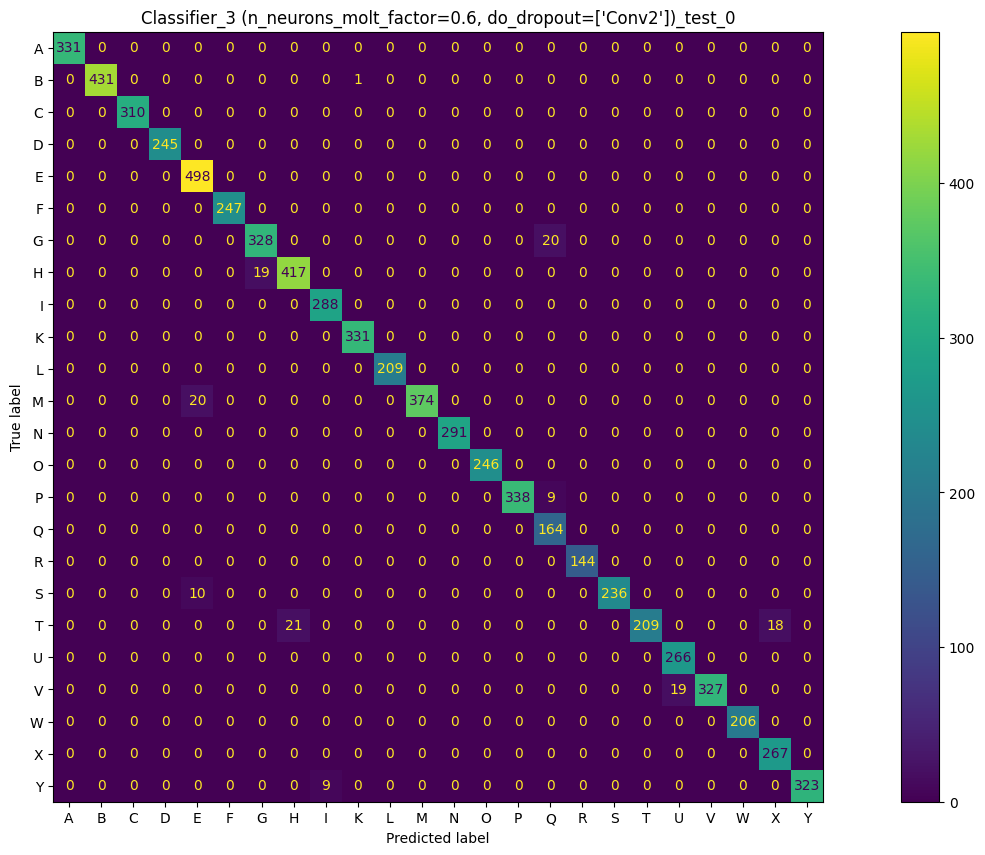

In [16]:
NeuralNetwork.load_NN(all_results.iloc[0], classifiers_dict, torch.device("cuda"), (28,28)).plot_confusion_matrix()

In [17]:
all_results.sort_values(by=['test_accuracies'], ascending=True).iloc[320:330]

,test_id,architecture_id,n_neurons_molt_factor,do_dropout,optimizer,lr,batch_size,patience,data_augmentation_perc,test_accuracies,test_times,train_times


In [18]:
model = NeuralNetwork.load_NN(all_results.iloc[2880], classifiers_dict, torch.device("cuda"), (28,28))
model.plot_confusion_matrix()

IndexError: single positional indexer is out-of-bounds

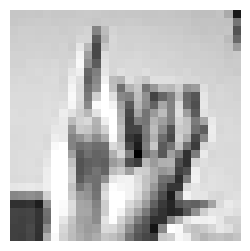

True label: I


{'A': 0.0,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.0,
 'H': 0.0,
 'I': 1.0,
 'J': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'O': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'U': 0.0,
 'V': 0.0,
 'W': 0.0,
 'X': 0.0,
 'Y': 0.0}

In [ ]:
image, response = sample_image(index = 10)
best_model.predict(image)